In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"]="1"
from typing import *

import json
import torch
import bisect
import warnings
import polars as pl
from tqdm.notebook import tqdm
from math import ceil
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

In [2]:

warnings.filterwarnings("ignore")
pl.Config.set_tbl_rows(50)
pl.Config.set_fmt_float("full")

polars.config.Config

In [3]:
class Tokenizer:
    def __init__(
        self,
        codes_parquet_fp: str,
        special_tokens: Optional[Iterable[str]] = None,
        force_special_ids: bool = True,  # pin [PAD]=0 etc.
    ):
        if special_tokens is None:
            special_tokens = ["[PAD]", "[MASK]", "[CLS]", "[UNK]"]


        df_codes = pl.read_parquet(str(codes_parquet_fp), columns=["code"])
        base_codes = df_codes.get_column("code").to_list()
        seen = set()
        unique_codes = []
        for c in base_codes:
            if c not in seen:
                unique_codes.append(c)
                seen.add(c)

        vocab_list: List[str] = []
        special_tokens = list(special_tokens)

        if force_special_ids:
            for tok in ["[PAD]", "[MASK]", "[CLS]", "[UNK]"]:
                if tok in special_tokens and tok not in seen:
                    vocab_list.append(tok)
                    seen.add(tok)
                elif tok in special_tokens and tok in seen:

                    vocab_list.append(tok)
            for tok in special_tokens:
                if tok not in seen:
                    vocab_list.append(tok)
                    seen.add(tok)
        else:
            for tok in special_tokens:
                if tok not in seen:
                    vocab_list.append(tok)
                    seen.add(tok)


        vocab_list.extend(unique_codes)


        self.id2code: List[str] = vocab_list
        self.code2id: Dict[str, int] = {tok: idx for idx, tok in enumerate(vocab_list)}
        self.vocab_size: int = len(self.id2code)

        self.pad_token  = "[PAD]" if "[PAD]" in self.code2id else None
        self.mask_token = "[MASK]" if "[MASK]" in self.code2id else None
        self.cls_token  = "[CLS]" if "[CLS]" in self.code2id else None
        self.unk_token  = "[UNK]" if "[UNK]" in self.code2id else None

        self.pad_id  = self.code2id[self.pad_token]  if self.pad_token  else 0
        self.mask_id = self.code2id[self.mask_token] if self.mask_token else None
        self.cls_id  = self.code2id[self.cls_token]  if self.cls_token  else None
        self.unk_id  = self.code2id[self.unk_token]  if self.unk_token  else None


        type_set = set()
        for tok in self.id2code:
            prefix = tok.split("//", 1)[0]
            type_set.add(prefix)

        types_sorted = sorted(t for t in type_set if t not in ("[PAD]",))
        self.type2id: Dict[str, int] = {"[PAD]": 0}
        next_id = 1
        for sp in ["[MASK]", "[CLS]", "[UNK]"]:
            if sp in type_set:
                self.type2id[sp] = next_id; next_id += 1
        for t in types_sorted:
            if t not in self.type2id:
                self.type2id[t] = next_id
                next_id += 1

        self._code2id_df = pl.DataFrame({"code": self.id2code,
                                         "input_id": list(range(self.vocab_size))}) \
                               .with_columns(pl.col("code").cast(pl.Categorical))
        self._type2id_df = pl.DataFrame({"code_type": list(self.type2id.keys()),
                                         "type_id":   list(self.type2id.values())}) \
                               .with_columns(pl.col("code_type").cast(pl.Categorical))


    def encode(self, codes: Iterable[str]) -> List[int]:
        get = self.code2id.get
        if self.unk_id is not None:
            fallback = self.unk_id
        else:
            fallback = self.pad_id if self.pad_id is not None else 0
        return [get(c, fallback) for c in codes]

    def decode(self, ids: Iterable[int]) -> List[str]:
        out = []
        for i in ids:
            if 0 <= i < self.vocab_size:
                out.append(self.id2code[i])
            else:
                out.append(self.unk_token or "[UNK]")
        return out

    def save(self, path: str) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        obj = {
            "id2code": self.id2code,
            "special_tokens": [t for t in ["[PAD]", "[MASK]", "[CLS]", "[UNK]"] if t in self.code2id],
            "type2id": self.type2id,
            "pad_id": self.pad_id,
            "mask_id": self.mask_id,
            "cls_id": self.cls_id,
            "unk_id": self.unk_id,
        }
        with open(path, "w") as f:
            json.dump(obj, f, indent=2)

    @classmethod
    def load(cls, path: str) -> "Tokenizer":
        path = Path(path)
        with open(path) as f:
            obj = json.load(f)

        tok = cls.__new__(cls) 

        tok.id2code = obj["id2code"]
        tok.code2id = {tok_: i for i, tok_ in enumerate(tok.id2code)}
        tok.vocab_size = len(tok.id2code)

        tok.special_tokens = obj.get("special_tokens", [])
        tok.type2id = obj.get("type2id", {})

        tok.pad_token  = "[PAD]" if "[PAD]" in tok.code2id else None
        tok.mask_token = "[MASK]" if "[MASK]" in tok.code2id else None
        tok.cls_token  = "[CLS]" if "[CLS]" in tok.code2id else None
        tok.unk_token  = "[UNK]" if "[UNK]" in tok.code2id else None

        tok.pad_id  = obj.get("pad_id", tok.code2id.get("[PAD]", 0))
        tok.mask_id = obj.get("mask_id", tok.code2id.get("[MASK]")) if "[MASK]" in tok.code2id else None
        tok.cls_id  = obj.get("cls_id", tok.code2id.get("[CLS]"))   if "[CLS]" in tok.code2id else None
        tok.unk_id  = obj.get("unk_id", tok.code2id.get("[UNK]"))   if "[UNK]" in tok.code2id else None

        # Rebuild Polars lookup frames
        tok._code2id_df = pl.DataFrame({"code": tok.id2code,
                                        "input_id": list(range(tok.vocab_size))}) \
                              .with_columns(pl.col("code").cast(pl.Categorical))
        tok._type2id_df = pl.DataFrame({"code_type": list(tok.type2id.keys()),
                                        "type_id":   list(tok.type2id.values())}) \
                              .with_columns(pl.col("code_type").cast(pl.Categorical))
        return tok

    @property
    def code2id_df(self) -> pl.DataFrame:
        return self._code2id_df

    @property
    def type2id_df(self) -> pl.DataFrame:
        return self._type2id_df

In [4]:
class SequencesGenerator:


    def __init__(
        self,
        tokenizer_path: str,
        chunk_length: int = 1024,
        overlap: int = 128,
        return_numeric: bool = False,
        return_text: bool = False,
    ):

        self.tokenizer = Tokenizer.load(tokenizer_path)
        self.chunk_length = chunk_length
        self.overlap = overlap
        self.return_numeric = return_numeric
        self.return_text = return_text

    def encode_sequence(
        self,
        timeline: pl.DataFrame,
        max_length: Optional[int] = None,
        pad_to_max: bool = False,
        truncation: Literal["head", "tail"] = "tail",
        add_cls: bool = False,
    ) -> Dict[str, Union[List[int], List[float], List[str]]]:
        """
        Vectorized build of:
          input_ids, attention_mask, visit_ids, stage_ids, type_ids
          + optional numeric/text streams (+ masks)
        """
        df = timeline

        # --- visit_ids (dense per-timeline integer ids starting at 1) ---
        # If seq_id exists -> categorical codes as stable ints; otherwise zeros.
        if "seq_id" in df.columns:
        # unique stable integer ids starting at 1
            uniq = df.select(pl.col("seq_id")).unique(maintain_order=True)
            uniq = uniq.with_row_count(name="visit_ids_raw")  # 0..K-1
            df = df.join(uniq, on="seq_id", how="left").with_columns(
                (pl.col("visit_ids_raw") ).alias("visit_id").fill_null(0)
            ).drop("visit_ids_raw")
        else:
            df = df.with_columns(pl.lit(0).alias("visit_id"))

        # --- stage_ids (first non-null of stage cols) ---
        stage_cols = ["out_id", "er_id", "hadm_id", "icustay_id"]
        present_stages = [c for c in stage_cols if c in df.columns]
        if present_stages:
            # Compute stage_id = 1..len(present_stages) or 0 if all null
            # We scan in the stage_cols order and pick the first non-null
            expr = pl.lit(0)
            for i, col in enumerate(present_stages, start=1):
                expr = pl.when(expr.eq(0) & pl.col(col).is_not_null()).then(i).otherwise(expr)
            df = df.with_columns(expr.alias("stage_id"))
        else:
            df = df.with_columns(pl.lit(0).alias("stage_id"))

        # --- map code_type -> type_id (PAD type=0 already in tokenizer) ---
        df = df.join(
            self.tokenizer.type2id_df,
            on=pl.col("code_type").cast(pl.Categorical),
            how="left",
        ).with_columns(pl.col("type_id").fill_null(0))

        # --- map code -> input_id (PAD=0, UNK fallback handled downstream) ---
        df = df.join(
            self.tokenizer.code2id_df,
            on=pl.col("code").cast(pl.Categorical),
            how="left",
        )

        # Fill unknown codes to UNK (or PAD if no UNK)
        unk_id = self.tokenizer.unk_id if self.tokenizer.unk_id is not None else self.tokenizer.pad_id or 0
        df = df.with_columns(pl.col("input_id").fill_null(unk_id))

        # --- TIME-GAP tokens zero out visit_id & stage_id (patient-agnostic) ---
        df = df.with_columns(
            pl.when(pl.col("code").str.starts_with("TIME-GAP//"))
              .then(0)
              .otherwise(pl.col("visit_id"))
              .alias("visit_id"),
            pl.when(pl.col("code").str.starts_with("TIME-GAP//"))
              .then(0)
              .otherwise(pl.col("stage_id"))
              .alias("stage_id"),
        )

        # --- Add [CLS] row if requested ---
        if add_cls and (self.tokenizer.cls_token is not None):
            cls_row = {
                "code": self.tokenizer.cls_token,
                "code_type": "[CLS]",
                "visit_id": 0,
                "stage_id": 0,
                "type_id": self.tokenizer.type2id.get("[CLS]", 0),
                "input_id": self.tokenizer.cls_id,
            }
            # Optional numeric/text placeholders
            if self.return_numeric:
                cls_row["numeric_value"] = None
            if self.return_text:
                cls_row["text_value"] = None

            df = pl.concat([pl.DataFrame([cls_row]), df], how="vertical_relaxed")

        # --- extract arrays ---
        input_ids = df.get_column("input_id").cast(pl.Int64).to_list()
        type_ids = df.get_column("type_id").cast(pl.Int64).to_list()
        visit_ids = df.get_column("visit_id").cast(pl.Int64).to_list()
        stage_ids = df.get_column("stage_id").cast(pl.Int64).to_list()
        attention_mask = [1] * len(input_ids)

        # --- optional value streams (numeric/text) ---
        value_payload = self._build_value_streams(
            df=df,
            max_length=max_length,
            pad_to_max=pad_to_max,
            truncation=truncation,
        )

        # --- truncate/pad core streams in one go ---
        input_ids      = self._truncate(input_ids,      max_length, truncation)
        type_ids       = self._truncate(type_ids,       max_length, truncation)
        visit_ids      = self._truncate(visit_ids,      max_length, truncation)
        stage_ids      = self._truncate(stage_ids,      max_length, truncation)
        attention_mask = [1] * len(input_ids)

        if pad_to_max and max_length is not None and len(input_ids) < max_length:
            pad_len = max_length - len(input_ids)
            pad_id = self.tokenizer.pad_id if self.tokenizer.pad_id is not None else 0
            input_ids      = input_ids + [pad_id] * pad_len
            type_ids       = type_ids + [0] * pad_len
            visit_ids      = visit_ids + [0] * pad_len
            stage_ids      = stage_ids + [0] * pad_len
            attention_mask = attention_mask + [0] * pad_len

        out = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "visit_ids": visit_ids,
            "stage_ids": stage_ids,
            "type_ids": type_ids,
        }
        out.update(value_payload)
        return out

    def get_overlapped_chunks(
        self,
        timeline: Dict[str, Iterable],
        chunk_length: Optional[int] = None,
        overlap: Optional[int] = None,
        add_cls_per_chunk: bool = True,
    ) -> List[Dict[str, List[Any]]]:
        """
        Sliding-window chunking with optional [CLS] per chunk and padding.
        """
        if chunk_length is None or overlap is None:
            chunk_length = self.chunk_length
            overlap = self.overlap

        fields = ["input_ids", "attention_mask", "visit_ids", "stage_ids", "type_ids"]
        for extra in ("numeric_values", "numeric_mask", "text_values", "text_mask"):
            if extra in timeline and extra not in fields:
                fields.append(extra)

        n = len(timeline["input_ids"])
        payload = chunk_length - (1 if add_cls_per_chunk else 0)
        step = max(1, payload - overlap)

        num_chunks = 1 if n <= payload else ceil((n - payload) / step) + 1
        starts = [i * step for i in range(num_chunks)]

        cls_defaults = {
            "input_ids": self.tokenizer.cls_id if self.tokenizer.cls_id is not None else (self.tokenizer.pad_id or 0),
            "attention_mask": 1,
            "visit_ids": 0,
            "stage_ids": 0,
            "type_ids": self.tokenizer.type2id.get("[CLS]", 0),
            "numeric_values": 0.0,
            "numeric_mask": 0,
            "text_values": "",
            "text_mask": 0,
        }

        chunks = []
        for start in starts:
            end = min(n, start + payload)
            sliced = {k: list(timeline[k][start:end]) for k in fields if k in timeline}

            if "attention_mask" in sliced:
                sliced["attention_mask"] = [1] * len(sliced["input_ids"])

            if add_cls_per_chunk:
                for k in list(sliced.keys()):
                    sliced[k] = [cls_defaults[k]] + sliced[k]

            cur_len = len(sliced["input_ids"])
            if cur_len < chunk_length:
                pad_len = chunk_length - cur_len
                for k in list(sliced.keys()):
                    sliced[k] = self._pad_list(sliced[k], pad_len, 0)

            chunks.append(sliced)
        return chunks


    def _build_value_streams(
        self,
        df: pl.DataFrame,
        max_length: Optional[int],
        pad_to_max: bool,
        truncation: Literal["head", "tail"],
    ) -> Dict[str, List[Any]]:
        out: Dict[str, List[Any]] = {}
        # Numeric stream
        if self.return_numeric:
            if "numeric_value" in df.columns:
                vals = df.get_column("numeric_value").to_list()
            else:
                vals = [None] * df.height
            num_mask = [1 if (v is not None) else 0 for v in vals]
            vals = [0.0 if v is None else float(v) for v in vals]

            vals = self._truncate(vals, max_length, truncation)
            num_mask = self._truncate(num_mask, max_length, truncation)

            if pad_to_max and max_length is not None and len(vals) < max_length:
                pad_len = max_length - len(vals)
                vals += [0.0] * pad_len
                num_mask += [0] * pad_len

            out["numeric_values"] = vals
            out["numeric_mask"] = num_mask

        # Text stream
        if self.return_text:
            if "text_value" in df.columns:
                txt = df.get_column("text_value").to_list()
            else:
                txt = [None] * df.height
            txt = [("" if (t is None or str(t) == "___") else str(t)) for t in txt]
            txt_mask = [1 if (t != "") else 0 for t in txt]

            txt = self._truncate(txt, max_length, truncation)
            txt_mask = self._truncate(txt_mask, max_length, truncation)

            if pad_to_max and max_length is not None and len(txt) < max_length:
                pad_len = max_length - len(txt)
                txt += [""] * pad_len
                txt_mask += [0] * pad_len

            out["text_values"] = txt
            out["text_mask"] = txt_mask

        return out

    @staticmethod
    def _truncate(seq: List[Any], max_length: Optional[int], truncation: str) -> List[Any]:
        if max_length is None or len(seq) <= max_length:
            return seq
        return seq[-max_length:] if truncation == "head" else seq[:max_length]

    @staticmethod
    def _pad_list(lst: List[Any], pad_len: int, pad_value: Any) -> List[Any]:
        if pad_len <= 0:
            return lst
        return lst + [pad_value] * pad_len

In [5]:
class EHRPretrainDataset(Dataset):
    def __init__(self,
                 data_path: str,
                 data_idx_path: str,
                 seq_generator: SequencesGenerator,
                 split: str = 'train') -> None:
        
        self.data_path = data_path
        self.seq_generator = seq_generator
        
        
        data_idx =  pl.scan_parquet(data_idx_path).collect()
        val_split = data_idx.sample(fraction=0.05, seed=24)
        train_split = data_idx.filter(pl.col('subject_id').is_in(val_split['subject_id'].to_list()) == False)


        self.data_idx, self.cum, self.subj = self._get_chunks_count(data_idx= train_split if split=='train' else val_split,
                                                                    chunk_length=self.seq_generator.chunk_length,
                                                                    overlap=self.seq_generator.overlap)
        
        
    def __len__(self) -> int:
        return self.cum[-1]


    
    def __getitem__(self,
                    index: int):
        

        subject_id, chunk_id = self._get_chunk_at_idx(idx=index,
                                                      cumm_sum=self.cum,
                                                      subjects=self.subj)
        timeline = self._read_timeline(subject_id)
        timeline_encoded = self.seq_generator.encode_sequence(timeline=timeline)
        chunks = self.seq_generator.get_overlapped_chunks(timeline= timeline_encoded,
                                                          chunk_length= self.seq_generator.chunk_length,
                                                          overlap=self.seq_generator.overlap)
        
#         chunk = self.seq_generator._return_tensors(chunks[chunk_id])
        return chunks[chunk_id]
    

    def _build_dataset_index(self,
                             data_path, 
                             subject_col="subject_id") -> pl.DataFrame:
        pieces = []
        for p in os.listdir(data_path):
            df = (pl.scan_parquet(os.path.join(data_path,p)).select(subject_col).collect()
                    .group_by(subject_col)
                    .len()
                    .rename({"len": "n_events"})
                 )
            df = df.with_columns(pl.lit(str(p)).alias("shard"))  # optional
            pieces.append(df)


        df = (pl.concat(pieces, how="vertical")
                  .group_by([subject_col, "shard"])
                  .agg(pl.col("n_events").sum())
                  .rename({subject_col:"subject_id"})).sort('subject_id')

        df = df.filter(pl.col('n_events') >3)

        return df
    
    
    def _read_timeline(self,
                       subject_id:int) -> pl.DataFrame:
        
        shard = self.data_idx.filter(pl.col('subject_id') == subject_id)['shard'][0]

        data = pl.scan_parquet(os.path.join(self.data_path,shard),parallel='auto').select(
                                            ['subject_id','seq_id','out_id','er_id','hadm_id', 
                                             'icustay_id','time','code','numeric_value','code_type',
                                             'text_value']).filter(
                                              pl.col('subject_id') == subject_id).collect()
        return data

    
    def _get_chunks_count(self,
                          data_idx: pl.DataFrame,
                          chunk_length: int,
                          overlap: int):
        payload  = chunk_length - 1
        step     = payload - overlap

        data_idx = data_idx.with_columns(
            pl.col("n_events")
              .map_elements(lambda n: 1 if n<=payload else ceil((n-payload)/step)+1,return_dtype=pl.Int32)
              .alias("n_chunks")
        )
        data_idx = data_idx.with_columns(
            pl.col("n_chunks").cum_sum().alias("cum_chunks")
        )

        cum  = data_idx["cum_chunks"]   
        subj = data_idx["subject_id"]
        shards = data_idx['shard']
        return data_idx, cum, subj

    def _get_chunk_at_idx(self,
                          cumm_sum: list,
                          subjects: list,
                          idx: int) -> Tuple[int,int,str]:
        i = bisect.bisect_right(cumm_sum, idx)
        left = cumm_sum[i-1] if i > 0 else 0
        return subjects[i], idx - left

In [6]:
class MLMDataCollator:
    def __init__(
        self,
        tokenizer,
        protected_tokens: List[str],
        mask_prob: float = 0.15,
        replace_prob: float = 0.80,
        random_prob: float = 0.10,
    ) -> None:

        self.tokenizer = tokenizer
        self.mask_prob = mask_prob
        self.replace_prob = replace_prob
        self.random_prob = random_prob
        self.protected_ids = self._build_protected_ids(protected_tokens)
        if tokenizer.mask_id is None:
            raise ValueError("Tokenizer must define a [MASK] token/id.")

    def __call__(self, batch: List[Union[Dict, List[Dict]]]) -> Dict[str, torch.Tensor]:
        chunks = self._flatten(batch)
        out = self._stack(chunks)
        masked_ids, labels = self._mask_batch(out["input_ids"], out["attention_mask"])
        out["input_ids"] = masked_ids
        out["labels"] = labels
        return out


    def _flatten(self, batch) -> List[Dict]:
        out: List[Dict] = []
        for item in batch:
            if isinstance(item, dict):
                out.append(item)
            elif isinstance(item, (list, tuple)):
                out.extend(item)
            else:
                raise TypeError(f"Unexpected item type: {type(item)}")
        if not out:
            raise ValueError("Empty batch after normalization.")
        return out

    def _stack(self, chunks: List[Dict]) -> Dict[str, torch.Tensor]:
        keys = list(chunks[0].keys())
        out = {}
        for k in keys:
            # Skip known non-numeric or variable-shaped fields
            if k in ("text_values",):  # add others you don't want to collate
                continue

            # Replace Nones with safe defaults
            seq_list = []
            for c in chunks:
                v = c[k]
                if isinstance(v, list):
                    v = [0 if x is None else x for x in v]  # 0 for ints/floats
                elif v is None:
                    # single value case (shouldn't happen for sequences, but guard anyway)
                    v = 0
                seq_list.append(torch.as_tensor(v))
            out[k] = torch.stack(seq_list, 0)
        return out

    def _build_protected_ids(self, protected_tokens: List[str]) -> torch.BoolTensor:

        ids = set()
        for tok in protected_tokens:
            if tok in self.tokenizer.code2id:
                ids.add(self.tokenizer.code2id[tok])
        mask = torch.zeros(self.tokenizer.vocab_size, dtype=torch.bool)
        for i in ids:
            mask[i] = True
        return mask

    def _mask_batch(
        self,
        input_ids: torch.Tensor,      # (B, L)
        attention_mask: torch.Tensor  # (B, L)
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Vectorized BERT-style masking:
        • 80% -> [MASK]
        • 10% -> random token (not protected)
        • 10% -> keep original
        Returns masked_input_ids, labels.
        """
        device = input_ids.device
        prot = self.protected_ids.to(device)
        eligible = attention_mask.bool() & (~prot[input_ids])

        sample = torch.rand_like(input_ids.float()) < self.mask_prob
        to_mask = eligible & sample

        masked = input_ids.clone()
        labels = torch.full_like(input_ids, -100)
        labels[to_mask] = input_ids[to_mask]

        r = torch.rand_like(input_ids.float())
        to_mask80 = to_mask & (r < self.replace_prob)
        to_rand10 = to_mask & (r >= self.replace_prob) & (r < self.replace_prob + self.random_prob)

        # 80% -> [MASK]
        masked[to_mask80] = self.tokenizer.mask_id

        # 10% -> random allowed token
        allowed = (~prot).nonzero(as_tuple=False).squeeze(1).to(device)
        if allowed.numel() == 0:
            allowed = torch.arange(self.tokenizer.vocab_size, device=device)
        if to_rand10.any():
            rand_ids = allowed[torch.randint(0, allowed.numel(), (to_rand10.sum(),), device=device)]
            masked[to_rand10] = rand_ids
        return masked, labels

In [7]:
PROTECTED_TOKENS = [
    "[PAD]", "[CLS]", "[MASK]",
    "OUTPATIENT-START","OUTPATIENT-END",
    "EMERGENCY-START","EMERGENCY-END",
    "ADMISSION-AT-HOSPITAL","ADMISSION-AT-ICU",
    "DISCHARGE-FROM-HOSPITAL","DISCHARGE-FROM-ICU"]

In [8]:
tokenizer_path = '../vocab.json'
data_path = '../data/meds_normalized/data/train/'
data_idx_path = '../dataset_idx.parquet'

seq_gen = SequencesGenerator(tokenizer_path= tokenizer_path,
                             chunk_length=30,
                             overlap=5,
                             return_numeric=True,
                             return_text=False)

train_dataset = EHRPretrainDataset(data_path=data_path,
                                   data_idx_path=data_idx_path,
                                   seq_generator=seq_gen,
                                   split='train')

val_dataset = EHRPretrainDataset(data_path=data_path,
                                 data_idx_path=data_idx_path,
                                 seq_generator=seq_gen,
                                 split='val')

collate_fn = MLMDataCollator(tokenizer=seq_gen.tokenizer,
                             protected_tokens=PROTECTED_TOKENS,
                             mask_prob=0.15,
                             replace_prob=0.8,
                             random_prob=0.1)

train_dataoader = DataLoader(dataset=train_dataset,
                             batch_size=5,
                             shuffle=True,
                             collate_fn=collate_fn)

val_dataoader = DataLoader(dataset=val_dataset,
                           batch_size=5,
                           shuffle=False,
                           collate_fn=collate_fn)


In [9]:
import os
import torch


import lightning as lt
import torch.nn as nn

from transformers import RoFormerForMaskedLM
from torchmetrics.classification import Accuracy

In [10]:
class EHREmbeddings(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_size: int,
        pad_token_id: int = 0,
        type_vocab_size: int = 28,
        visit_vocab_size: int = 102,
        stage_vocab_size: int = 5,
        dropout: float = 0.1
    ):
        super().__init__()
        self.tok_emb   = nn.Embedding(vocab_size, embedding_size, padding_idx=pad_token_id)
        self.type_emb  = nn.Embedding(type_vocab_size,  embedding_size, padding_idx=pad_token_id)
        self.visit_emb = nn.Embedding(visit_vocab_size, embedding_size, padding_idx=pad_token_id)
        self.stage_emb = nn.Embedding(stage_vocab_size, embedding_size, padding_idx=pad_token_id)
        self.norm      = nn.LayerNorm(embedding_size)
        self.drop      = nn.Dropout(dropout)

    def encode(self, input_ids, type_ids, visit_ids, stage_ids):
        x = self.tok_emb(input_ids.long())
        x = x + self.type_emb(type_ids.long())
        x = x + self.visit_emb(visit_ids.long())
        x = x + self.stage_emb(stage_ids.long())
        return self.drop(self.norm(x))


    def forward(self, input_ids=None, 
                token_type_ids=None, 
                inputs_embeds=None,
                **kwargs):
        if inputs_embeds is not None:
            return inputs_embeds
        return self.drop(self.norm(self.tok_emb(input_ids.long())))

In [11]:
class MLMPretraining(lt.LightningModule):
    def __init__(
        self,
        config,
        lr: float = 2e-5,
        wd: float = 0.001,
        max_epochs: int = 100,
        dropout: float = 0.1,
        pretrained: bool = False
    ):
        super().__init__()
        self.save_hyperparameters()

        self.top_1_train = Accuracy(task="multiclass", num_classes=config.vocab_size, top_k=1,ignore_index=-100)
        self.top_3_train = Accuracy(task="multiclass", num_classes=config.vocab_size, top_k=3,ignore_index=-100)
        self.top_5_train = Accuracy(task="multiclass", num_classes=config.vocab_size, top_k=5,ignore_index=-100)

        self.top_1_val = Accuracy(task="multiclass", num_classes=config.vocab_size, top_k=1,ignore_index=-100)
        self.top_3_val = Accuracy(task="multiclass", num_classes=config.vocab_size, top_k=3,ignore_index=-100)
        self.top_5_val = Accuracy(task="multiclass", num_classes=config.vocab_size, top_k=5,ignore_index=-100)

        self.backbone = RoFormerForMaskedLM(config)
        
        if pretrained:
            self.get_pretrained_weights(self.backbone)

        ehr_emb = EHREmbeddings(
            vocab_size=config.vocab_size, 
            embedding_size=config.embedding_size, 
            pad_token_id=config.pad_token_id,
            type_vocab_size=config.type_vocab_size, 
            visit_vocab_size=config.visit_vocab_size,
            stage_vocab_size=config.stage_vocab_size, 
            dropout=dropout)
        
        self.backbone.roformer.embeddings = ehr_emb
        self.backbone.cls.predictions.decoder.weight = self.backbone.roformer.embeddings.tok_emb.weight

        self.lr = lr
        self.wd = wd
        self.max_epochs = max_epochs



    def forward(self, 
                input_ids, 
                attention_mask, 
                type_ids, 
                visit_ids, 
                stage_ids, 
                labels=None):
        
        inputs_embeds = self.backbone.roformer.embeddings.encode(
        input_ids=input_ids,
        type_ids=type_ids,
        visit_ids=visit_ids,
        stage_ids=stage_ids)
        return self.backbone(inputs_embeds=inputs_embeds,
                             attention_mask=attention_mask,
                             labels=labels)


    def training_step(self, batch, batch_idx):
        out = self.forward(input_ids=batch["input_ids"],
                            attention_mask=batch["attention_mask"],
                            type_ids=batch["type_ids"],
                            visit_ids=batch["visit_ids"],
                            stage_ids=batch["stage_ids"],
                            labels=batch["labels"])
        
        loss = out.loss
        preds  = out.logits.view(-1, out.logits.size(-1))
        target = batch["labels"].view(-1)

        top1 = self.top_1_train(preds, target)
        top3 = self.top_3_train(preds, target)
        top5 = self.top_5_train(preds, target)
        perplexity = torch.exp(loss)

        self.log("train_perplexity", perplexity, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        self.log("train_loss", loss, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        self.log("train_top1", top1, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        self.log("train_top3", top3, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        self.log("train_top5", top5, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        out = self(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            type_ids=batch["type_ids"],
            visit_ids=batch["visit_ids"],
            stage_ids=batch["stage_ids"],
            labels=batch["labels"])
        
        loss = out.loss
        preds  = out.logits.view(-1, out.logits.size(-1))
        target = batch["labels"].view(-1)
        
        top1 = self.top_1_val(preds, target)
        top3 = self.top_3_val(preds, target)
        top5 = self.top_5_val(preds, target)
        perplexity = torch.exp(loss)

        self.log("val_perplexity", perplexity, prog_bar=False, on_step=False, on_epoch=True, sync_dist=True)
        self.log("val_loss", loss, prog_bar=False, on_step=False, on_epoch=True, sync_dist=True)
        self.log("val_top1", top1, prog_bar=False, on_step=False, on_epoch=True, sync_dist=True)
        self.log("val_top3", top3, prog_bar=False, on_step=False, on_epoch=True, sync_dist=True)
        self.log("val_top5", top5, prog_bar=False, on_step=False, on_epoch=True, sync_dist=True)

    def configure_optimizers(self):


        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr,weight_decay=self.wd)
        
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer,
                                                         eta_min=0,
                                                         T_max=self.max_epochs
                                                         )
        
        return {'optimizer': optimizer,
                'lr_scheduler': scheduler}
    

    def get_pretrained_weights(self,
                               model: nn.Module,
                               hf_ckpt: str = "junnyu/roformer_chinese_base") -> None:
        state = RoFormerForMaskedLM.from_pretrained(hf_ckpt,
                                                    ignore_mismatched_sizes=True).state_dict()
        drop_prefixes = ("cls.",
                         "roformer.embeddings.", 
                         "roformer.encoder.embed_positions.weight")
        filtered = {k: v for k, v in state.items() if not k.startswith(drop_prefixes)}

        missing, unexpected = model.load_state_dict(filtered, strict=False)

In [12]:
import os
import torch
import wandb
import argparse

import lightning.pytorch as lt
from transformers import RoFormerConfig

In [13]:
cfg = RoFormerConfig(
    vocab_size=seq_gen.tokenizer.vocab_size,
    hidden_size=768,
    num_hidden_layers=12,
    num_attention_heads=12,
    intermediate_size=3072,
    max_position_embeddings=1024,
    pad_token_id=seq_gen.tokenizer.pad_id,
    type_vocab_size= 28,
    visit_vocab_size= 102,
    stage_vocab_size= 5)

# model = MLMPretraining(config=cfg,pretrained=False)

# Evaluation setting

In [16]:
ckpt = '/scratch/sas10092/ehr-foundation/models/mlm/wandb/run-20250925_120754-Roformer_base_12116792_1536_192/files/ckpt/epoch=23-step=407928.ckpt'
weights = torch.load(ckpt,map_location='cpu',weights_only=False)['state_dict']
# weights = {k[9:]:v for k,v in weights.items() }

In [17]:
# data_idx = get_mortality_labels(data_path=data_path)

In [59]:
from transformers import RoFormerForSequenceClassification
from torchmetrics.classification import BinaryAccuracy, BinaryAUROC, BinaryAveragePrecision

In [60]:
class EmbedEvalModel(lt.LightningModule):
    def __init__(
        self,
        config,
        embed: bool = True,
        ckpt_path: str = None,
        num_classes: int = 2,
        lr: float = 2e-5,
        wd: float = 0.001,
        max_epochs: int = 100,
        dropout: float = 0.1,
        pretrained: bool = False,
        freeze: bool = False
    ):
        super().__init__()
        self.save_hyperparameters()
        self.config = config
        self.backbone = RoFormerForSequenceClassification(self.config)
        
        self.train_step_preds = []
        self.train_step_label = []
        self.val_step_preds = []
        self.val_step_label = []
        self.test_step_preds = []
        self.test_step_label = []

        ehr_emb = EHREmbeddings(
            vocab_size=config.vocab_size, 
            embedding_size=config.embedding_size, 
            pad_token_id=config.pad_token_id,
            type_vocab_size=config.type_vocab_size, 
            visit_vocab_size=config.visit_vocab_size,
            stage_vocab_size=config.stage_vocab_size, 
            dropout=dropout)
        
        self.backbone.roformer.embeddings = ehr_emb
        
        if pretrained:
            self.get_pretrained_weights(model= self.backbone,
                                       ckpt_path=ckpt_path)
        if freeze:
            for param in self.backbone.parameters():
                param.requires_grad = False

            # Unfreeze classifier head
            for param in self.backbone.classifier.parameters():
                param.requires_grad = True

        if embed:
            self.backbone.classifier = nn.Identity()


        self.lr = lr
        self.wd = wd
        self.max_epochs = max_epochs
        

        self.train_auroc = BinaryAUROC()
        self.train_auprc = BinaryAveragePrecision()
        self.val_auroc = BinaryAUROC()
        self.val_auprc = BinaryAveragePrecision()
        self.test_auroc = BinaryAUROC()
        self.test_auprc = BinaryAveragePrecision()


    def forward(self, 
                input_ids, 
                attention_mask, 
                type_ids, 
                visit_ids, 
                stage_ids, 
                labels=None):
        
        inputs_embeds = self.backbone.roformer.embeddings.encode(
        input_ids=input_ids,
        type_ids=type_ids,
        visit_ids=visit_ids,
        stage_ids=stage_ids)
        return self.backbone(inputs_embeds=inputs_embeds,
                             attention_mask=attention_mask,
                             labels=labels)


    def training_step(self, batch, batch_idx):
        out = self.forward(input_ids=batch["input_ids"],
                            attention_mask=batch["attention_mask"],
                            type_ids=batch["type_ids"],
                            visit_ids=batch["visit_ids"],
                            stage_ids=batch["stage_ids"],
                            labels=batch["labels"])
        
        loss = out.loss
        logits = out.logits 
        
        y = batch["labels"].long()   # [B] with {0,1}
        pos_score = torch.softmax(logits, dim=-1)[:, 1]  # probability of class 1

        self.train_step_label.append(y)
        self.train_step_preds.append(pos_score)

        self.log("train_loss", loss, prog_bar=True, on_epoch=True,logger=True)

        return loss

    def on_train_epoch_end(self) -> None:
        
        y = torch.cat(self.train_step_label)
        pos_score = torch.cat(self.train_step_preds)

        auroc = self.train_auroc(pos_score, y)
        auprc = self.train_auprc(pos_score, y)
        
        self.log('train_auroc',auroc, on_epoch=True, logger=True)
        self.log('train_auprc',auprc, on_epoch=True, logger=True)  
        
        self.train_step_label.clear()
        self.train_step_preds.clear()

    def validation_step(self, batch, batch_idx):
        out = self.forward(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            type_ids=batch["type_ids"],
            visit_ids=batch["visit_ids"],
            stage_ids=batch["stage_ids"],
            labels=batch["labels"])
        
        loss = out.loss
        logits = out.logits 
        
        y = batch["labels"].long()  
        pos_score = torch.softmax(logits, dim=-1)[:, 1] 

        self.val_step_label.append(y)
        self.val_step_preds.append(pos_score)

        self.log("val_loss", loss, prog_bar=True, on_epoch=True,logger=True)
        
        return loss


    def on_validation_epoch_end(self,*arg, **kwargs) -> None:
        
        y = torch.cat(self.val_step_label)
        pos_score = torch.cat(self.val_step_preds)

        auroc = self.val_auroc(pos_score, y)
        auprc = self.val_auprc(pos_score, y)
        
        self.log('val_auroc',auroc, on_epoch=True, logger=True)
        self.log('val_auprc',auprc, on_epoch=True, logger=True)  
        
        self.val_step_label.clear()
        self.val_step_preds.clear()   
    

    def test_step(self, batch, batch_idx):
        out = self.forward(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            type_ids=batch["type_ids"],
            visit_ids=batch["visit_ids"],
            stage_ids=batch["stage_ids"],
            labels=batch["labels"])
        
        loss = out.loss
        logits = out.logits 
        
        y = batch["labels"].long()  
        pos_score = torch.softmax(logits, dim=-1)[:, 1] 

        self.test_step_label.append(y)
        self.test_step_preds.append(pos_score)

        self.log("test_loss", loss, prog_bar=True, on_epoch=True,logger=True)
        return loss    
    

    def on_test_epoch_end(self,*arg, **kwargs) -> None:
        
        y = torch.cat(self.test_step_label)
        pos_score = torch.cat(self.test_step_preds)

        auroc = self.test_auroc(pos_score, y)
        auprc = self.test_auprc(pos_score, y)
        
        self.log('test_auroc',auroc, on_epoch=True, logger=True)
        self.log('test_auprc',auprc, on_epoch=True, logger=True)  
        
        self.test_step_label.clear()
        self.test_step_preds.clear()  
    
    
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr,weight_decay=self.wd)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer,
                                                         eta_min=0,
                                                         T_max=self.max_epochs
                                                         )
        return {'optimizer': optimizer, 'lr_scheduler': scheduler}
    

    def get_pretrained_weights(self,
                               model: nn.Module,
                               ckpt_path: str) -> None:
        
        weights = torch.load(ckpt_path, map_location='cpu',weights_only=False)['state_dict']
        weights = {k[9:]: v for k, v in weights.items()}
        missing, unexpected = model.load_state_dict(weights, strict=False)
        print("weights loaded successfully!")
        print(missing)
        print('+'*50)
        print(unexpected)

In [61]:
class EmbedEvalCollator:
    def __init__(self) -> None:
        pass


    def __call__(self, batch: List[Union[Dict, List[Dict]]]) -> Dict[str, torch.Tensor]:
        chunks = self._flatten(batch)
        out = self._stack(chunks)
        
        return out


    def _flatten(self, batch) -> List[Dict]:
        out: List[Dict] = []
        for item in batch:
            if isinstance(item, dict):
                out.append(item)
            elif isinstance(item, (list, tuple)):
                out.extend(item)
            else:
                raise TypeError(f"Unexpected item type: {type(item)}")
        if not out:
            raise ValueError("Empty batch after normalization.")
        return out

    def _stack(self, chunks: List[Dict]) -> Dict[str, torch.Tensor]:
        keys = list(chunks[0].keys())
        out = {}
        for k in keys:
            # Skip known non-numeric or variable-shaped fields
            if k in ("text_values",):  # add others you don't want to collate
                continue

            # Replace Nones with safe defaults
            seq_list = []
            for c in chunks:
                v = c[k]
                if isinstance(v, list):
                    v = [0 if x is None else x for x in v]  # 0 for ints/floats
                elif v is None:
                    # single value case (shouldn't happen for sequences, but guard anyway)
                    v = 0
                seq_list.append(torch.as_tensor(v))
            out[k] = torch.stack(seq_list, 0)
        return out

In [62]:
from sklearn.model_selection import train_test_split
class EvalEmbedDataset(Dataset):
    def __init__(self,
                 data_path: str,
                 data_idx_path: str,
                 seq_generator: SequencesGenerator,
                 split: str = 'train') -> None:
        
        self.data_path = data_path
        self.seq_generator = seq_generator
        
        
        data_idx =  pl.scan_parquet(data_idx_path).collect()
        
        train_split,val_split = train_test_split(data_idx,
                                                 train_size=0.8, 
                                                 test_size=0.2, 
                                                 random_state=24,
                                                 stratify=data_idx['died_in_hosp'])


        self.data_idx, self.cum, self.subj, self.labels = self._get_chunks_count(data_idx= train_split if split=='train' else val_split,
                                                                                 chunk_length=self.seq_generator.chunk_length,
                                                                                 overlap=self.seq_generator.overlap)
        
        
    def __len__(self) -> int:
        return self.cum[-1]


    
    def __getitem__(self,
                    index: int):
        

        subject_id, chunk_id, label = self._get_chunk_at_idx(idx=index,
                                                             cumm_sum=self.cum,
                                                             subjects=self.subj,
                                                             labels=self.labels )
        timeline = self._read_timeline(subject_id)
        timeline_encoded = self.seq_generator.encode_sequence(timeline=timeline)
        chunks = self.seq_generator.get_overlapped_chunks(timeline= timeline_encoded,
                                                          chunk_length= self.seq_generator.chunk_length,
                                                          overlap=self.seq_generator.overlap)
        
        chunk = chunks[chunk_id]
        chunk['labels'] = label

        return chunk
    

    def _build_dataset_index(self,
                             data_path, 
                             subject_col="subject_id") -> pl.DataFrame:
        pieces = []
        for p in os.listdir(data_path):
            df = (pl.scan_parquet(os.path.join(data_path,p)).select(subject_col).collect()
                    .group_by(subject_col)
                    .len()
                    .rename({"len": "n_events"})
                 )
            df = df.with_columns(pl.lit(str(p)).alias("shard"))  # optional
            pieces.append(df)


        df = (pl.concat(pieces, how="vertical")
                  .group_by([subject_col, "shard"])
                  .agg(pl.col("n_events").sum())
                  .rename({subject_col:"subject_id"})).sort('subject_id')

        df = df.filter(pl.col('n_events') >3)

        return df
    
    
    def _read_timeline(self,
                       subject_id:int) -> pl.DataFrame:
        
        shard = self.data_idx.filter(pl.col('subject_id') == subject_id)['shard'][0]

        data = pl.scan_parquet(os.path.join(self.data_path,shard),parallel='auto').select(
                                            ['subject_id','seq_id','out_id','er_id','hadm_id', 
                                             'icustay_id','time','code','numeric_value','code_type',
                                             'text_value']).filter(
                                              pl.col('subject_id') == subject_id).collect()
        return data

    
    def _get_chunks_count(self,
                          data_idx: pl.DataFrame,
                          chunk_length: int,
                          overlap: int):
        payload  = chunk_length - 1
        step     = payload - overlap

        data_idx = data_idx.with_columns(
            pl.col("n_events")
              .map_elements(lambda n: 1 if n<=payload else ceil((n-payload)/step)+1,return_dtype=pl.Int32)
              .alias("n_chunks")
        )
        data_idx = data_idx.with_columns(
            pl.col("n_chunks").cum_sum().alias("cum_chunks")
        )

        cum  = data_idx["cum_chunks"]   
        subj = data_idx["subject_id"]
        shards = data_idx['shard']
        labels = data_idx['died_in_hosp']
        return data_idx, cum, subj, labels

    def _get_chunk_at_idx(self,
                          cumm_sum: list,
                          subjects: list,
                          labels:list,
                          idx: int) -> Tuple[int,int,str]:
        i = bisect.bisect_right(cumm_sum, idx)
        left = cumm_sum[i-1] if i > 0 else 0
        return subjects[i], idx - left, labels[i]

In [63]:
seq_gen_eval = SequencesGenerator(tokenizer_path=tokenizer_path,
                                  chunk_length=1536,
                                  overlap=0)

collate_fn = EmbedEvalCollator()

train_dataset = EvalEmbedDataset(data_path=data_path,
                                 data_idx_path='./mortality_labels.parquet',
                                 seq_generator=seq_gen_eval,
                                 split= 'train')

val_dataset = EvalEmbedDataset(data_path=data_path,
                                 data_idx_path='./mortality_labels.parquet',
                                 seq_generator=seq_gen_eval,
                                 split= 'val')


train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=16,
                              shuffle=True,
#                               num_workers=16,
                              collate_fn=collate_fn)

val_dataloader = DataLoader(dataset=val_dataset,
                            batch_size=16,
                            shuffle=False,
                            collate_fn=collate_fn)

In [64]:
cfg = RoFormerConfig(
    vocab_size=seq_gen_eval.tokenizer.vocab_size,
    hidden_size=768,
    num_hidden_layers=12,
    num_attention_heads=12,
    intermediate_size=3072,
    max_position_embeddings=1536,
    pad_token_id=seq_gen.tokenizer.pad_id,
    type_vocab_size= 28,
    visit_vocab_size= 102,
    stage_vocab_size= 5,
    num_labels=2)

In [68]:
model = EmbedEvalModel(config=cfg,
                       embed= False,
                       ckpt_path=None,
                       lr=1e-5,
                       wd=0.001,
                       max_epochs=50,
                      pretrained=False)

In [66]:
total_params = sum(param.numel() for param in model.backbone.classifier.parameters() if param.requires_grad ==True)
print(f"Total parameters: {total_params/1000_000}")

Total parameters: 0.59213


In [33]:
for param in model.parameters():
    param.requires_grad = False

# Unfreeze classifier head
for param in model.backbone.classifier.parameters():
    param.requires_grad = True

In [ ]:
# torch.set_float32_matmul_precision('high')
# trainer = lt.Trainer(accelerator='gpu', 
#                     devices='auto',
#                     strategy='auto',
# #                     logger=wandb_logger, 
#                     log_every_n_steps=1,
#                     num_sanity_val_steps=0,
#                     max_epochs=10,
#                     precision='16-mixed', 
# #                     callbacks=[checkpoint_callback,early_stop,lr_monitor]
#                     )

# trainer.fit(model=model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

Using 16bit Automatic Mixed Precision (AMP)
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                              | Params | Mode 
--------------------------------------------------------------------------
0 | backbone    | RoFormerForSequenceClassification | 122 M  | train
1 | train_auroc | BinaryAUROC                       | 0      | train
2 | train_auprc | BinaryAveragePrecision            | 0      | train
3 | val_auroc   | BinaryAUROC                       | 0      | train
4 | val_auprc   | BinaryAveragePrecision            | 0      | train
5 | test_auroc  | BinaryAUROC                       | 0      | train
6 | test_auprc  | BinaryAveragePrecision            | 0      | train
------------

Training: |          | 0/? [00:00<?, ?it/s]

(np.float64(1.728830921649933),
 np.float64(7.992662084102631),
 np.float64(1.287551498413086),
 np.float64(7.577236557006836))

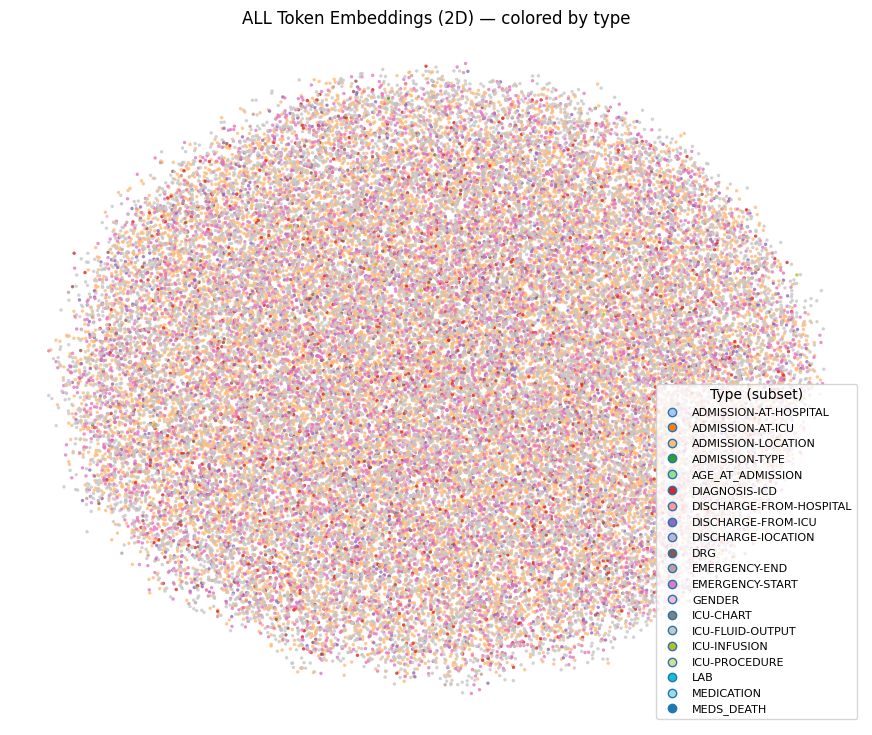

In [69]:
# ===== 0) Setup: put your type dict here =====
TYPE2ID = {
 'ADMISSION-AT-HOSPITAL': 1, 'ADMISSION-AT-ICU': 2, 'ADMISSION-LOCATION': 3, 'ADMISSION-TYPE': 4,
 'AGE_AT_ADMISSION': 5, 'DIAGNOSIS-ICD': 6, 'DISCHARGE-FROM-HOSPITAL': 7, 'DISCHARGE-FROM-ICU': 8,
 'DISCHARGE-lOCATION': 9, 'DRG': 10, 'EMERGENCY-END': 11, 'EMERGENCY-START': 12, 'GENDER': 13,
 'ICU-CHART': 14, 'ICU-FLUID-OUTPUT': 15, 'ICU-INFUSION': 16, 'ICU-PROCEDURE': 17, 'LAB': 18,
 'MEDICATION': 19, 'MEDS_DEATH': 20, 'MICROBIOLOGY': 21, 'OUTPATIENT-END': 22, 'OUTPATIENT-START': 23,
 'PROCEDURE-ICD': 24, 'RACE': 25, 'TIME-GAP': 26, '[CLS]': 27, '[MASK]': 28, '[PAD]': 29, '[UNK]': 30
}
ID2TYPE = {v:k for k,v in TYPE2ID.items()}

# ===== 1) Grab the embedding matrix =====
import torch
W = model.backbone.roformer.embeddings.tok_emb.weight.detach().cpu()
W = torch.nn.functional.normalize(W, p=2, dim=1)




# ===== 2) Map token-id -> token string & type-id =====
# Adapt these two helpers to YOUR tokenizer/tables.
def tok_from_id(tid:int)->str:
    # works for HF tokenizers
    return seq_gen_evaltokenizer.convert_ids_to_tokens([tid])[0]

def typeid_from_token(tok:str)->int:
    """
    Return the integer type-id for a token string.
    You should replace this with your own lookup (e.g., tokenizer.code->type_id).
    If unknown, return TYPE2ID['[UNK]'].
    """
    # Example heuristics: tokens look like "LAB//..." or "ICU-CHART//..."
    # Map by prefix before '//' or up to first '-' block.
    t = tok.split('//', 1)[0]
    return TYPE2ID.get(t, TYPE2ID['[UNK]'])

tok_list = seq_gen_eval.tokenizer.id2code
types = [typeid_from_token(t) for t in tok_list]






import numpy as np
X = W.numpy()

# ===== 3) Dimensionality reduction (PCA -> UMAP or t-SNE) =====
from sklearn.decomposition import PCA
Xr = PCA(n_components=50, random_state=0).fit_transform(X)

try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=0)
    XY = reducer.fit_transform(Xr)
except Exception:
    from sklearn.manifold import TSNE
    XY = TSNE(n_components=2, perplexity=30, metric="cosine", init="pca", random_state=0).fit_transform(Xr)

# ===== 4) Scatter plot (ALL tokens), color by type-id =====
import matplotlib.pyplot as plt
import matplotlib.cm as cm

types_arr = np.array(types)
plt.figure(figsize=(11, 9))
sc = plt.scatter(XY[:,0], XY[:,1], s=6, c=types_arr, cmap='tab20', alpha=0.8, linewidths=0)

# Legend (cap to 20 to keep readable)
uniq_types = sorted(set(types_arr))
legend_items = uniq_types[:20]
handles = [plt.Line2D([0],[0], marker='o', linestyle='', label=ID2TYPE[i],
                      markerfacecolor=cm.get_cmap('tab20')(i % 20), markersize=6)
           for i in legend_items]
plt.legend(handles=handles, title="Type (subset)", fontsize=8, loc="best")

plt.title("ALL Token Embeddings (2D) — colored by type")
plt.axis('off')

# # Annotate a small random subset of tokens (scatter already has ALL points)
# rng = np.random.RandomState(0)
# annot_idx = rng.choice(len(tok_list), size=min(400, len(tok_list)), replace=False)
# for i in annot_idx:
#     plt.text(XY[i,0], XY[i,1], tok_list[i], fontsize=5, alpha=0.6)

# plt.tight_layout()
# plt.show()

# # ===== 5) Quick sanity: k-NN type-purity =====
# from sklearn.neighbors import NearestNeighbors
# k = 10
# nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(X)  # use original embedding space
# _, idxs = nbrs.kneighbors(X)
# purity = []
# for i, neigh in enumerate(idxs):
#     neigh = neigh[1:]  # drop self
#     purity.append(np.mean(types_arr[neigh] == types_arr[i]))
# print("Mean k-NN type purity (k=10):", float(np.mean(purity)))

(np.float64(2.195571517944336),
 np.float64(8.447491073608399),
 np.float64(1.7677199840545654),
 np.float64(7.995067834854126))

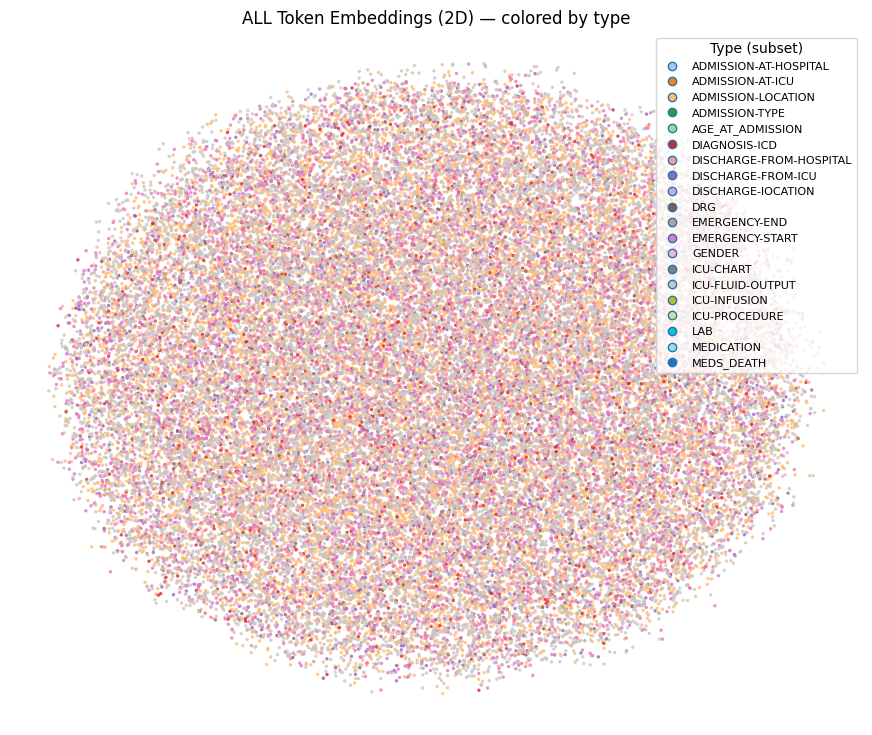

In [67]:
# ===== 0) Setup: put your type dict here =====
TYPE2ID = {
 'ADMISSION-AT-HOSPITAL': 1, 'ADMISSION-AT-ICU': 2, 'ADMISSION-LOCATION': 3, 'ADMISSION-TYPE': 4,
 'AGE_AT_ADMISSION': 5, 'DIAGNOSIS-ICD': 6, 'DISCHARGE-FROM-HOSPITAL': 7, 'DISCHARGE-FROM-ICU': 8,
 'DISCHARGE-lOCATION': 9, 'DRG': 10, 'EMERGENCY-END': 11, 'EMERGENCY-START': 12, 'GENDER': 13,
 'ICU-CHART': 14, 'ICU-FLUID-OUTPUT': 15, 'ICU-INFUSION': 16, 'ICU-PROCEDURE': 17, 'LAB': 18,
 'MEDICATION': 19, 'MEDS_DEATH': 20, 'MICROBIOLOGY': 21, 'OUTPATIENT-END': 22, 'OUTPATIENT-START': 23,
 'PROCEDURE-ICD': 24, 'RACE': 25, 'TIME-GAP': 26, '[CLS]': 27, '[MASK]': 28, '[PAD]': 29, '[UNK]': 30
}
ID2TYPE = {v:k for k,v in TYPE2ID.items()}

# ===== 1) Grab the embedding matrix =====
import torch
W = model.backbone.roformer.embeddings.tok_emb.weight.detach().cpu()
W = torch.nn.functional.normalize(W, p=2, dim=1)




# ===== 2) Map token-id -> token string & type-id =====
# Adapt these two helpers to YOUR tokenizer/tables.
def tok_from_id(tid:int)->str:
    # works for HF tokenizers
    return seq_gen_evaltokenizer.convert_ids_to_tokens([tid])[0]

def typeid_from_token(tok:str)->int:
    """
    Return the integer type-id for a token string.
    You should replace this with your own lookup (e.g., tokenizer.code->type_id).
    If unknown, return TYPE2ID['[UNK]'].
    """
    # Example heuristics: tokens look like "LAB//..." or "ICU-CHART//..."
    # Map by prefix before '//' or up to first '-' block.
    t = tok.split('//', 1)[0]
    return TYPE2ID.get(t, TYPE2ID['[UNK]'])

tok_list = seq_gen_eval.tokenizer.id2code
types = [typeid_from_token(t) for t in tok_list]






import numpy as np
X = W.numpy()

# ===== 3) Dimensionality reduction (PCA -> UMAP or t-SNE) =====
from sklearn.decomposition import PCA
Xr = PCA(n_components=50, random_state=0).fit_transform(X)

try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=0)
    XY = reducer.fit_transform(Xr)
except Exception:
    from sklearn.manifold import TSNE
    XY = TSNE(n_components=2, perplexity=30, metric="cosine", init="pca", random_state=0).fit_transform(Xr)

# ===== 4) Scatter plot (ALL tokens), color by type-id =====
import matplotlib.pyplot as plt
import matplotlib.cm as cm

types_arr = np.array(types)
plt.figure(figsize=(11, 9))
sc = plt.scatter(XY[:,0], XY[:,1], s=6, c=types_arr, cmap='tab20', alpha=0.8, linewidths=0)

# Legend (cap to 20 to keep readable)
uniq_types = sorted(set(types_arr))
legend_items = uniq_types[:20]
handles = [plt.Line2D([0],[0], marker='o', linestyle='', label=ID2TYPE[i],
                      markerfacecolor=cm.get_cmap('tab20')(i % 20), markersize=6)
           for i in legend_items]
plt.legend(handles=handles, title="Type (subset)", fontsize=8, loc="best")

plt.title("ALL Token Embeddings (2D) — colored by type")
plt.axis('off')

# # Annotate a small random subset of tokens (scatter already has ALL points)
# rng = np.random.RandomState(0)
# annot_idx = rng.choice(len(tok_list), size=min(400, len(tok_list)), replace=False)
# for i in annot_idx:
#     plt.text(XY[i,0], XY[i,1], tok_list[i], fontsize=5, alpha=0.6)

# plt.tight_layout()
# plt.show()

# # ===== 5) Quick sanity: k-NN type-purity =====
# from sklearn.neighbors import NearestNeighbors
# k = 10
# nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(X)  # use original embedding space
# _, idxs = nbrs.kneighbors(X)
# purity = []
# for i, neigh in enumerate(idxs):
#     neigh = neigh[1:]  # drop self
#     purity.append(np.mean(types_arr[neigh] == types_arr[i]))
# print("Mean k-NN type purity (k=10):", float(np.mean(purity)))

In [ ]:
# # embedding with numirical values incorporated

# #import torch
# import torch.nn as nn

class EHREmbeddings(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_size: int,
        pad_token_id: int = 0,
        type_vocab_size: int = 28,
        visit_vocab_size: int = 102,
        stage_vocab_size: int = 5,
        dropout: float = 0.1,
        use_numeric: bool = True,
    ):
        super().__init__()
        self.use_numeric = use_numeric
        self.tok_emb   = nn.Embedding(vocab_size, embedding_size, padding_idx=pad_token_id)
        self.type_emb  = nn.Embedding(type_vocab_size, embedding_size, padding_idx=0)
        self.visit_emb = nn.Embedding(visit_vocab_size, embedding_size, padding_idx=0)
        self.stage_emb = nn.Embedding(stage_vocab_size, embedding_size, padding_idx=0)

        if self.use_numeric:
            self.num_proj = nn.Linear(1, embedding_size)
            # learned vector for missing numeric values
            self.null = nn.Parameter(torch.zeros(embedding_size))
            nn.init.normal_(self.null, mean=0.0, std=0.02)
            nn.init.xavier_uniform_(self.num_proj.weight)
            nn.init.zeros_(self.num_proj.bias)

        self.norm = nn.LayerNorm(embedding_size)
        self.drop = nn.Dropout(dropout)

    def _numeric_embedding(self, numeric_values: torch.Tensor, numeric_mask: torch.Tensor) -> torch.Tensor:
        # numeric_values: (B, L) normalized floats
        # numeric_mask:   (B, L) bool/int
        v = numeric_values.float().unsqueeze(-1)        # (B,L,1)
        num_emb = self.num_proj(v)                      # (B,L,d)
        mask = numeric_mask.bool().unsqueeze(-1)        # (B,L,1)
        # fill missing with learned absent vector
        num_emb = torch.where(mask, num_emb, self.null.view(1,1,-1))
        return num_emb

    def encode(
        self,
        input_ids: torch.Tensor,
        type_ids: torch.Tensor,
        visit_ids: torch.Tensor,
        stage_ids: torch.Tensor,
        numeric_values: torch.Tensor = None,
        numeric_mask: torch.Tensor = None,
        attention_mask: torch.Tensor = None,
    ) -> torch.Tensor:
        x = ( self.tok_emb(input_ids.long())
            + self.type_emb(type_ids.long())
            + self.visit_emb(visit_ids.long())
            + self.stage_emb(stage_ids.long()) )

        if self.use_numeric and numeric_values is not None and numeric_mask is not None:
            x = x + self._numeric_embedding(numeric_values, numeric_mask)

        if attention_mask is not None:
            x = x * attention_mask.unsqueeze(-1).to(x.dtype)

        return self.drop(self.norm(x))

    def forward(self, input_ids=None, token_type_ids=None, inputs_embeds=None, **kwargs):
        if inputs_embeds is not None:
            return inputs_embeds
        # fallback for HF API
        return self.drop(self.norm(self.tok_emb(input_ids.long())))